# 4. Word2Vec-style embeddings

This notebook learns small **Word2Vec-style embeddings** from `observations.csv`.

The fictional-language tokens are treated as words. We build target/context pairs from a symmetric context window and learn vectors using a skip-gram-like **logistic objective with negative sampling**.

We compare:

- window **2**: one token before + one token after;
- window **4**: two tokens before + two tokens after;
- embedding dimensions **2** and **3**.

The resulting vectors are plotted as lines from the origin to each token.

> This is a pedagogical implementation. It exposes the vectors and the logistic objective directly rather than using a Word2Vec library.


In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Configuration
INPUT_FILE = "../01-observations/observations.csv"
WINDOW_SIZES = [2, 4]
EMBEDDING_DIMS = [2, 3]
NEGATIVE_SAMPLES_PER_POSITIVE = 3
EPOCHS = 800
LEARNING_RATE = 0.05
BATCH_SIZE = 64
RANDOM_SEED = 42

if RANDOM_SEED is not None:
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)


In [2]:
# Read observations
df = pd.read_csv(INPUT_FILE)
sentences = [s.split() for s in df["sentence"]]

vocabulary = sorted(set(t for s in sentences for t in s))
token_to_id = {t: i for i, t in enumerate(vocabulary)}

print(f"Observations: {len(sentences)}")
print(f"Vocabulary: {vocabulary}")
print(f"Vocabulary size: {len(vocabulary)}")


Observations: 850
Vocabulary: ['e', 'f', 'l', 'p', 'r', 's']
Vocabulary size: 6


## Build target/context pairs

With window 2, a target sees one token on either side.

With window 4, a target sees up to two tokens on either side.

These are the positive examples for the skip-gram objective.


In [3]:
def build_positive_pairs(sequences, window_size):
    radius = window_size // 2
    pairs = []
    for sentence in sequences:
        for i, target in enumerate(sentence):
            lo = max(0, i - radius)
            hi = min(len(sentence), i + radius + 1)
            for j in range(lo, hi):
                if i != j:
                    pairs.append((target, sentence[j]))
    return pairs

for w in WINDOW_SIZES:
    pairs = build_positive_pairs(sentences, w)
    print(f"Window {w}: {len(pairs)} positive pairs")


Window 2: 6850 positive pairs
Window 4: 12000 positive pairs


## Logistic-regression view of Word2Vec

For target vector \(v_w\) and context vector \(u_c\), the pair score is

\[
score(w,c)=v_w \cdot u_c.
\]

The logistic probability is

\[
P(y=1|w,c)=\sigma(v_w\cdot u_c).
\]

Observed target/context pairs have \(y=1\); randomly sampled pairs have \(y=0\).

### Negative sampling

For every observed pair, `NEGATIVE_SAMPLES_PER_POSITIVE` negative contexts are drawn from the *noise distribution*

\[
P_n(c) \propto \text{count}(c)^{3/4},
\]

and fresh negatives are drawn at every epoch. As in the original Word2Vec, negatives are **not** filtered against the observed pairs. With only six tokens, most target/context pairs occur somewhere in the corpus (with window 2, `r` co-occurs with every token, itself included), so requiring a never-observed context would leave some targets with no possible negative. A negative that happens to be a real context just gets a small wrong label, and the frequent true pairs outweigh it.

Training uses mini-batches: the pairs in each batch are updated together with NumPy instead of one at a time in a Python loop.

We optimize the binary cross-entropy directly. This gives a compact implementation of the central Word2Vec idea while keeping the learned embedding vectors visible.


In [4]:
def sigmoid(x):
    x = np.clip(x, -30, 30)
    return 1 / (1 + np.exp(-x))

def train_embeddings(sequences, window_size, dim, epochs=EPOCHS,
                     learning_rate=LEARNING_RATE,
                     negative_ratio=NEGATIVE_SAMPLES_PER_POSITIVE,
                     batch_size=BATCH_SIZE,
                     seed=42):
    rng = np.random.default_rng(seed)
    V = len(vocabulary)

    # Separate target and context vectors, as in skip-gram.
    W = rng.normal(0, 0.15, (V, dim))
    U = rng.normal(0, 0.15, (V, dim))

    # Positive pairs: every observed occurrence, as token ids.
    positive = build_positive_pairs(sequences, window_size)
    pos_targets = np.array([token_to_id[t] for t, _ in positive])
    pos_contexts = np.array([token_to_id[c] for _, c in positive])

    # Noise distribution for negative sampling: unigram frequency ^ 3/4.
    token_counts = Counter(t for s in sequences for t in s)
    noise = np.array([token_counts[t] for t in vocabulary], dtype=float) ** 0.75
    noise /= noise.sum()

    losses = []

    for epoch in range(epochs):
        # Fresh negatives each epoch: negative_ratio per positive pair.
        neg_targets = np.repeat(pos_targets, negative_ratio)
        neg_contexts = rng.choice(V, size=len(neg_targets), p=noise)

        targets = np.concatenate([pos_targets, neg_targets])
        contexts = np.concatenate([pos_contexts, neg_contexts])
        labels = np.concatenate([np.ones(len(pos_targets)),
                                 np.zeros(len(neg_targets))])

        order = rng.permutation(len(targets))
        targets, contexts, labels = targets[order], contexts[order], labels[order]

        # Mini-batch stochastic gradient descent.
        total_loss = 0.0

        for start in range(0, len(targets), batch_size):
            wi = targets[start:start + batch_size]
            ci = contexts[start:start + batch_size]
            y = labels[start:start + batch_size]

            v = W[wi]
            u = U[ci]

            score = np.sum(v * u, axis=1)
            prob = sigmoid(score)
            error = (prob - y)[:, None]

            # np.add.at accumulates correctly when a token repeats in the batch.
            np.add.at(W, wi, -learning_rate * error * u)
            np.add.at(U, ci, -learning_rate * error * v)

            total_loss += np.sum(-(y*np.log(prob+1e-12) +
                                   (1-y)*np.log(1-prob+1e-12)))

        if epoch % max(1, epochs//10) == 0:
            losses.append(total_loss / len(targets))

    embeddings = pd.DataFrame(W, index=vocabulary)
    embeddings.index.name = "token"
    return embeddings, losses

## Train the four configurations

We train:

- window 2 × dimension 2
- window 2 × dimension 3
- window 4 × dimension 2
- window 4 × dimension 3


In [5]:
models = {}

for window in WINDOW_SIZES:
    for dim in EMBEDDING_DIMS:
        print(f"Training window={window}, dimension={dim}")
        emb, losses = train_embeddings(
            sentences, window, dim,
            seed=(RANDOM_SEED or 0) + window*100 + dim
        )
        models[(window, dim)] = {"embeddings": emb, "losses": losses}
        display(emb.round(3))


Training window=2, dimension=2


,0,1
token,,
e,-2.603,1.824
f,-0.558,0.309
l,0.332,1.569
p,-0.659,0.528
r,-0.059,1.016
s,0.654,1.666


Training window=2, dimension=3


,0,1,2
token,,,
e,0.400,-2.405,1.859
f,-1.282,0.118,1.227
l,0.287,0.786,1.257
p,-1.259,0.139,1.393
r,-0.131,-0.606,0.844
s,1.734,0.292,1.759


Training window=4, dimension=2


,0,1
token,,
e,1.387,1.881
f,-1.314,0.830
l,0.005,1.172
p,-1.143,1.044
r,0.010,1.085
s,0.228,1.284


Training window=4, dimension=3


,0,1,2
token,,,
e,1.085,1.144,1.669
f,0.815,-1.510,0.270
l,0.352,-0.249,1.308
p,0.915,-1.359,0.527
r,0.558,-0.446,0.242
s,2.022,0.004,-0.232


## 2D embeddings

Each line starts at the origin and ends at the learned vector for one token.


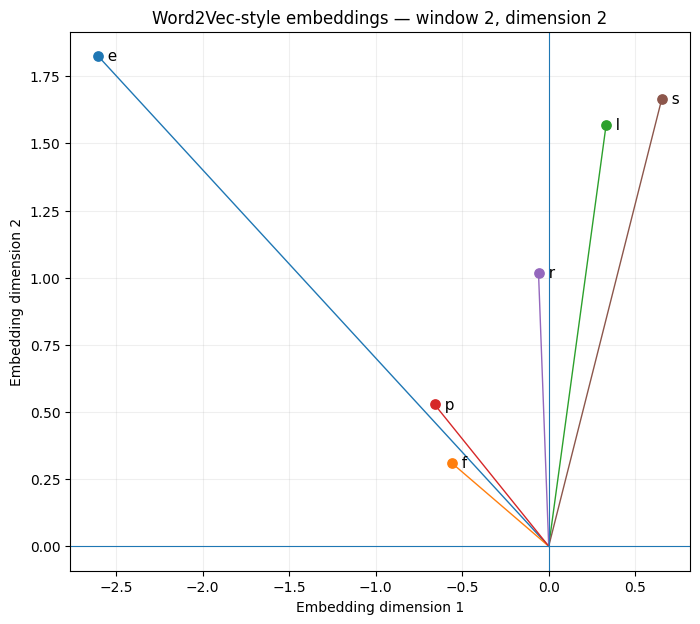

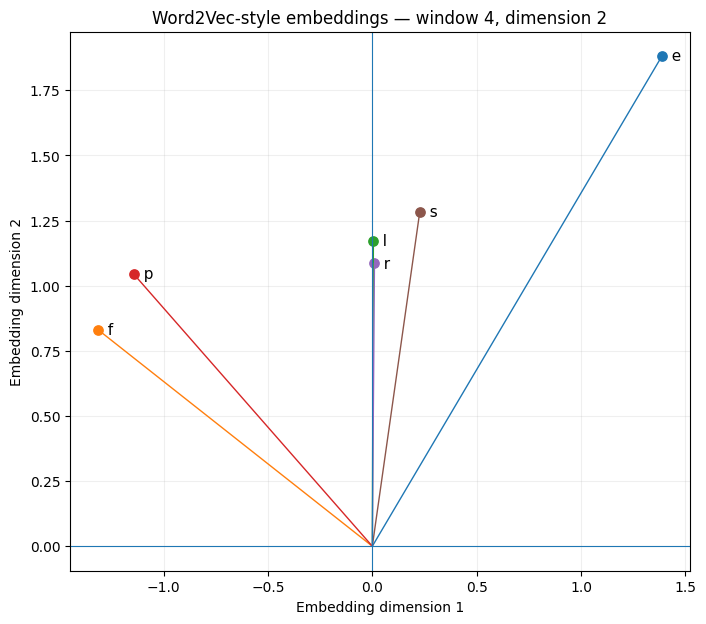

In [6]:
def plot_2d(embeddings, title):
    fig, ax = plt.subplots(figsize=(8, 7))
    for token, row in embeddings.iterrows():
        x, y = row.iloc[0], row.iloc[1]
        ax.plot([0, x], [0, y], linewidth=1)
        ax.scatter([x], [y], s=45)
        ax.text(x, y, f"  {token}", fontsize=11, va="center")
    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)
    ax.set_xlabel("Embedding dimension 1")
    ax.set_ylabel("Embedding dimension 2")
    ax.set_title(title)
    ax.grid(True, alpha=0.2)
    plt.show()

for window in WINDOW_SIZES:
    plot_2d(models[(window, 2)]["embeddings"],
            f"Word2Vec-style embeddings — window {window}, dimension 2")


## 3D embeddings

Again, each line starts at the origin and ends at the token's learned vector.


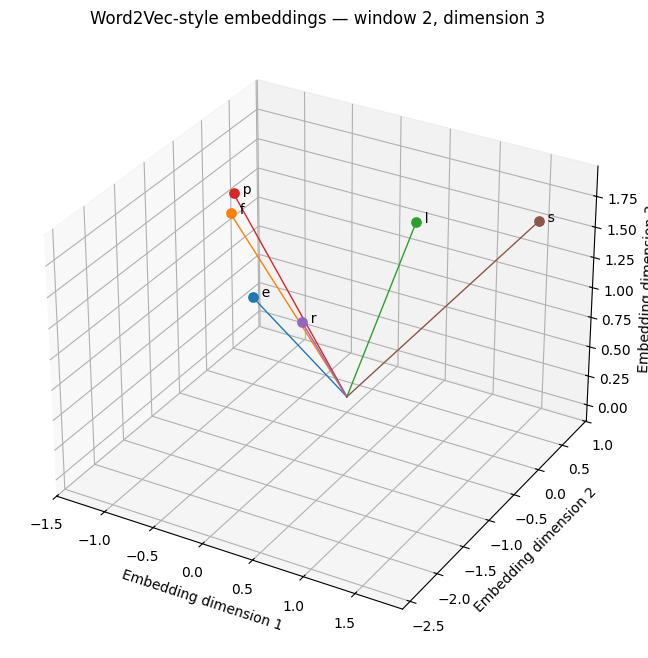

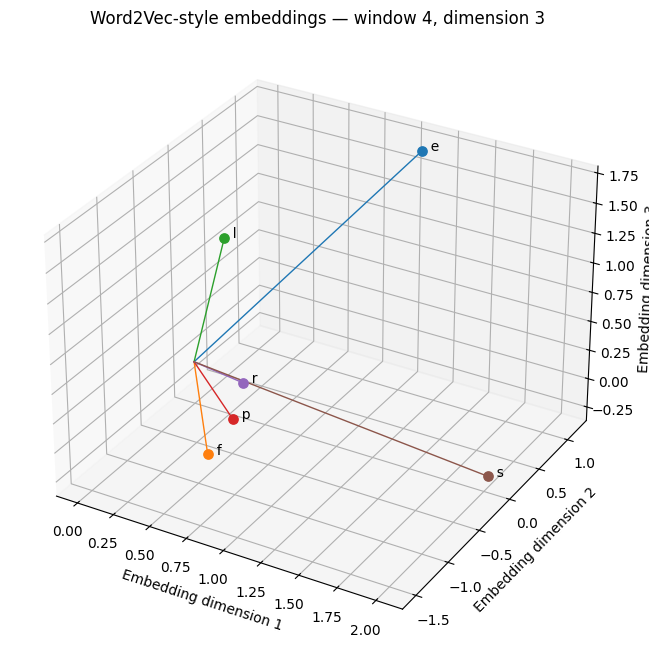

In [7]:
def plot_3d(embeddings, title):
    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection="3d")
    for token, row in embeddings.iterrows():
        x, y, z = row.iloc[0], row.iloc[1], row.iloc[2]
        ax.plot([0, x], [0, y], [0, z], linewidth=1)
        ax.scatter([x], [y], [z], s=45)
        ax.text(x, y, z, f"  {token}", fontsize=10)
    ax.set_xlabel("Embedding dimension 1")
    ax.set_ylabel("Embedding dimension 2")
    ax.set_zlabel("Embedding dimension 3")
    ax.set_title(title)
    plt.show()

for window in WINDOW_SIZES:
    plot_3d(models[(window, 3)]["embeddings"],
            f"Word2Vec-style embeddings — window {window}, dimension 3")


## Cosine similarity

The embedding vectors can also be compared by cosine similarity.


In [8]:
def cosine_similarity_matrix(embeddings):
    X = embeddings.to_numpy()
    X = X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), 1e-12)
    return pd.DataFrame(X @ X.T, index=embeddings.index, columns=embeddings.index)

for (window, dim), model in models.items():
    print(f"Window={window}, dimension={dim}")
    display(cosine_similarity_matrix(model["embeddings"]).round(3))


Window=2, dimension=2


token,e,f,l,p,r,s
token,,,,,,
e,1.000,0.994,0.392,0.998,0.620,0.235
f,0.994,1.000,0.293,0.986,0.534,0.131
l,0.392,0.293,1.000,0.450,0.965,0.986
p,0.998,0.986,0.450,1.000,0.669,0.297
r,0.620,0.534,0.965,0.669,1.000,0.908
s,0.235,0.131,0.986,0.297,0.908,1.000


Window=2, dimension=3


token,e,f,l,p,r,s
token,,,,,,
e,1.000,0.272,0.121,0.304,0.926,0.428
f,0.272,1.000,0.472,0.997,0.608,-0.007
l,0.121,0.472,1.000,0.527,0.345,0.782
p,0.304,0.997,0.527,1.000,0.637,0.066
r,0.926,0.608,0.345,0.637,1.000,0.415
s,0.428,-0.007,0.782,0.066,0.415,1.000


Window=4, dimension=2


token,e,f,l,p,r,s
token,,,,,,
e,1.000,-0.072,0.807,0.105,0.810,0.896
f,-0.072,1.000,0.531,0.984,0.526,0.379
l,0.807,0.531,1.000,0.671,1.000,0.985
p,0.105,0.984,0.671,1.000,0.668,0.535
r,0.810,0.526,1.000,0.668,1.000,0.986
s,0.896,0.379,0.985,0.535,0.986,1.000


Window=4, dimension=3


token,e,f,l,p,r,s
token,,,,,,
e,1.000,-0.099,0.721,0.081,0.288,0.388
f,-0.099,1.000,0.424,0.983,0.911,0.447
l,0.721,0.424,1.000,0.570,0.600,0.145
p,0.081,0.983,0.570,1.000,0.958,0.492
r,0.288,0.911,0.600,0.958,1.000,0.698
s,0.388,0.447,0.145,0.492,0.698,1.000


In [9]:
# ------------------------------------------------------------
# Save embeddings and cosine similarities
# ------------------------------------------------------------
#
# One pair of CSV files is produced for each configuration.
# The names encode the context window and embedding dimension.

def save_embedding_results(models):
    for (window, dim), model in models.items():
        embeddings = model["embeddings"]

        embedding_file = f"embeddings-{window}-gram-{dim}d-matrix.csv"
        similarity_file = f"embeddings-{window}-gram-{dim}d-cosine-similarity.csv"

        # Embedding matrix: one row per token, one column per dimension.
        embeddings.to_csv(embedding_file)

        # Cosine similarity matrix: tokens in both rows and columns.
        similarity = cosine_similarity_matrix(embeddings)
        similarity.to_csv(similarity_file)

        print(f"Saved: {embedding_file}")
        print(f"Saved: {similarity_file}")


save_embedding_results(models)


Saved: embeddings-2-gram-2d-matrix.csv
Saved: embeddings-2-gram-2d-cosine-similarity.csv
Saved: embeddings-2-gram-3d-matrix.csv
Saved: embeddings-2-gram-3d-cosine-similarity.csv
Saved: embeddings-4-gram-2d-matrix.csv
Saved: embeddings-4-gram-2d-cosine-similarity.csv
Saved: embeddings-4-gram-3d-matrix.csv
Saved: embeddings-4-gram-3d-cosine-similarity.csv
